In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import EFC_learningfMRI.globals as gl
from EFC_learningfMRI.vis import plot_behav_sess, plot_im_sess
import os

In [2]:
pinfo = pd.read_csv(os.path.join(gl.baseDir, 'participants.tsv'), sep='\t')
pinfo = pinfo[['sn', 'sex', 'good']]
print(pinfo[pinfo.sn.isin(gl.participants)])
colorm, colorf = ['royalblue', 'lightsteelblue'], ['hotpink', 'lightpink']
hue_order = ['trained', 'untrained']

     sn sex good
3   101   m    1
4   102   f    1
5   103   f    1
6   104   m    1
7   105   f    1
8   106   f    1
9   107   f    1
10  108   f    1
12  110   m    1
13  111   m    1
14  112   m    1
15  113   f    1
16  114   f    1


In [3]:
path = os.path.join(gl.baseDir, 'behavioural')
df_sess_corr = pd.read_csv(os.path.join(path, 'behaviour.session.success.tsv'), sep='\t')
df_sess_corr = df_sess_corr.rename(columns={'subNum': 'sn'})
df_sess_corr = df_sess_corr.merge(pinfo, on=['sn'])

/home/UWO/memanue5/Documents/GitHub/EFC_learningfMRI/venv/lib/python3.10/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


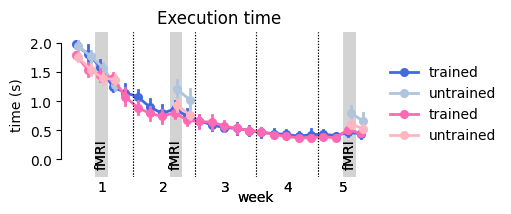

In [4]:
fig, ax = plt.subplots(figsize=(5, 2), constrained_layout=True)
ax.set_ylim((-.3, 2.2))
ax.spines['left'].set_bounds(0, 2)
ax.set_ylabel('time (s)')
ax.set_title('Execution time')
plot_behav_sess(fig, ax, df_sess_corr[df_sess_corr.sex=='m'], x='session', y='ET', hue='chord', hue_order=hue_order, palette=colorm) 
plot_behav_sess(fig, ax, df_sess_corr[df_sess_corr.sex=='f'], x='session', y='ET', hue='chord', hue_order=hue_order, palette=colorf) 
ax.legend(bbox_to_anchor=(1, .5), loc='center left', frameon=False)
plt.show()

/home/UWO/memanue5/Documents/GitHub/EFC_learningfMRI/venv/lib/python3.10/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


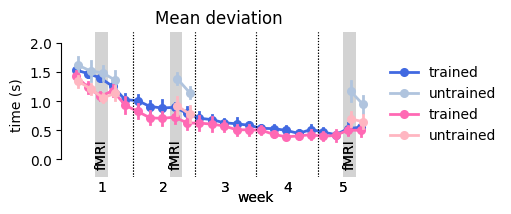

In [7]:
fig, ax = plt.subplots(figsize=(5, 2), constrained_layout=True)
ax.set_ylim((-.3, 2.2))
ax.spines['left'].set_bounds(0, 2)
ax.set_ylabel('time (s)')
ax.set_title('Mean deviation')
plot_behav_sess(fig, ax, df_sess_corr[df_sess_corr.sex=='m'], x='session', y='MD', hue='chord', hue_order=hue_order, palette=colorm) 
plot_behav_sess(fig, ax, df_sess_corr[df_sess_corr.sex=='f'], x='session', y='MD', hue='chord', hue_order=hue_order, palette=colorf) 
ax.legend(bbox_to_anchor=(1, .5), loc='center left', frameon=False)
plt.show()

In [8]:
H = 'L'
atlas = 'ROI'
rois = gl.rois[atlas]
glm = 3
stat = 'nanmean'
activation = pd.read_csv(os.path.join(gl.baseDir, f'glm{glm}', 'ROI.activation.tsv'), sep='\t')
N = activation.sn.nunique()
activation = activation.groupby(['chord', 'session', 'sn', 'regionname', 'Hem']).mean(numeric_only=True).reset_index()
activation = activation[activation.Hem==H]
activation = activation.merge(pinfo, on=['sn'])

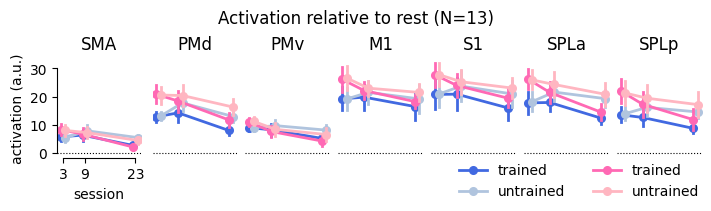

In [15]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)
plot_im_sess(fig, axs, activation[activation.sex=='m'], rois=rois, roi_col='regionname', y=stat, hue='chord', hue_order=hue_order, palette=colorm, add_zero=True)
plot_im_sess(fig, axs, activation[activation.sex=='f'], rois=rois, roi_col='regionname', y=stat, hue='chord', hue_order=hue_order, palette=colorf)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('activation (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right', ncol=2)
axs[0].set_xlabel('session')
fig.suptitle(f'Activation relative to rest (N={N})')
plt.show()

In [16]:
dist = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist = dist[(dist.Hem==H) & (dist.chord.isin(['trained', 'untrained']))]
dist_chord_sess = dist.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()
dist_chord_sess = dist_chord_sess.merge(pinfo, on=['sn'])

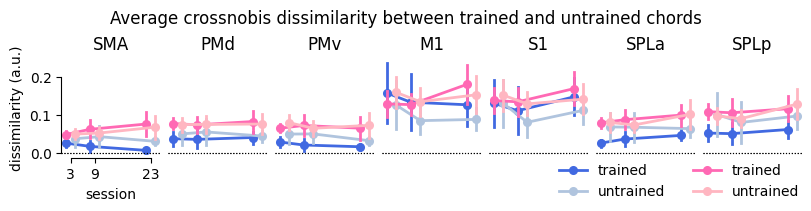

In [25]:

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess[dist_chord_sess.sex=='m'], rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=colorm, kind='point', dodge=.4, add_zero=True)
plot_im_sess(fig, axs, dist_chord_sess[dist_chord_sess.sex=='f'], rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=colorf, kind='point', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('dissimilarity (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right', ncol=2)
axs[0].set_xlabel('session')

fig.suptitle('Average crossnobis dissimilarity between trained and untrained chords')

plt.show()